In [1]:
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict, NotRequired

from pprint import pprint
import json

In [2]:
class MicroscopeState(TypedDict):
    scan_size: float
    scan_resolution: float
    scan_rate: float
    drive_amplitude: float
    central_frequency: float
    frequency_width: float
    dc_offset: float
    feedback_on: bool
    x_offset: float
    y_offset: float
    set_point: float

class PFMExperimentState(TypedDict):
    main_task: NotRequired[str]

    microscope_state: NotRequired[MicroscopeState]
    experiment_directory: NotRequired[str]
    

    



In [3]:
from spm_agent.mcp.spm_mcp_client import SPMMCPClient

In [4]:
def _to_microscope_state(state_dict: dict) -> MicroscopeState:
    return MicroscopeState(
        scan_size=state_dict["scan_size"],
        scan_resolution=state_dict["n_points"],
        scan_rate=state_dict["scan_rate"],
        drive_amplitude=state_dict["v_ac"],
        central_frequency=state_dict["f_dart"],
        frequency_width=state_dict["f_width"],
        dc_offset=state_dict["v_dc"],
        feedback_on=state_dict["feedback_on"],
        x_offset=state_dict["x_offset"],
        y_offset=state_dict["y_offset"],
        set_point=state_dict["setpoint"],
    )

In [12]:
async def get_status_node(state: PFMExperimentState) -> PFMExperimentState:
    spm_client = SPMMCPClient()
    result = await spm_client.call_tool("pfm_get_experiment_status")

    res_dict = json.loads(result[0]['text'])
    print(result[0]['text'])
    if res_dict['ok']:
        state_dict = res_dict['data']
        mic_state = _to_microscope_state(state_dict)
        directory = state_dict.get("directory", None)
    
    
    return {
        "microscope_state": mic_state,
        "experiment_directory": directory
        }

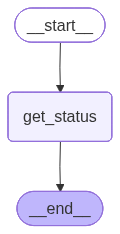

In [14]:
builder = StateGraph(PFMExperimentState)
builder.add_node('get_status', get_status_node)

builder.add_edge(START, 'get_status')
builder.add_edge('get_status', END)

graph = builder.compile()
graph 

In [17]:
result = await graph.ainvoke({})

{"ok":true,"data":{"scan_size":9.9999997e-6,"n_points":512,"scan_rate":0.70382881,"v_ac":0.5,"v_dc":0.0,"f_dart":384899.28,"f_width":10000.0,"setpoint":0.2,"feedback_on":false,"stage_x":-0.00091687503,"stage_y":0.0028003126,"x_offset":0.0,"y_offset":0.0,"directory":"C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260602","message":"Instrument status read successfully."},"audit":{"ts_unix":1780442798.7468877,"request_id":"4620feae-3751-430e-8112-d86b7ca8c4e4","instrument_id":"asylum-aespm","tool":"pfm.get_experiment_status","operator_id":null,"config_snapshot":{}}}


In [18]:
pprint(result)

{'experiment_directory': 'C:\\Users\\Asylum User\\Documents\\Asylum Research '
                         'Data\\260602',
 'microscope_state': {'central_frequency': 384899.28,
                      'dc_offset': 0.0,
                      'drive_amplitude': 0.5,
                      'feedback_on': False,
                      'frequency_width': 10000.0,
                      'scan_rate': 0.70382881,
                      'scan_resolution': 512,
                      'scan_size': 9.9999997e-06,
                      'set_point': 0.2,
                      'x_offset': 0.0,
                      'y_offset': 0.0}}


In [35]:
tool = next(t for t in tools if t.name == "pfm_get_experiment_status")

In [43]:
result = await tool.ainvoke({})

In [ ]:
result[0]

[{'type': 'text', 'text': '{"ok":true,"data":{"scan_size":9.9999997e-6,"n_points":512,"scan_rate":0.70382881,"v_ac":0.5,"v_dc":0.0,"f_dart":384899.28,"f_width":10000.0,"setpoint":0.2,"feedback_on":false,"stage_x":-0.00091687503,"stage_y":0.0028003126,"x_offset":0.0,"y_offset":0.0,"message":"Instrument status read successfully."},"audit":{"ts_unix":1780440309.8563821,"request_id":"6d4d123a-0e56-4065-b6f9-3a599d37159e","instrument_id":"asylum-aespm","tool":"pfm.get_experiment_status","operator_id":null,"config_snapshot":{}}}', 'id': 'lc_9e837286-6d62-48a7-a93e-40b3d65f90f6'}]

In [14]:
pprint(json.loads(result[0]['text']))

{'audit': {'config_snapshot': {},
           'instrument_id': 'asylum-aespm',
           'operator_id': None,
           'request_id': '6d4d123a-0e56-4065-b6f9-3a599d37159e',
           'tool': 'pfm.get_experiment_status',
           'ts_unix': 1780440309.8563821},
 'data': {'f_dart': 384899.28,
          'f_width': 10000.0,
          'feedback_on': False,
          'message': 'Instrument status read successfully.',
          'n_points': 512,
          'scan_rate': 0.70382881,
          'scan_size': 9.9999997e-06,
          'setpoint': 0.2,
          'stage_x': -0.00091687503,
          'stage_y': 0.0028003126,
          'v_ac': 0.5,
          'v_dc': 0.0,
          'x_offset': 0.0,
          'y_offset': 0.0},
 'ok': True}


In [ ]:
result[0]['text'].json_dump()

AttributeError: 'str' object has no attribute 'model_dump'